# Restaurant Revenue Prediction Project

**Course:** Big Data Analytics
**Problem:** Restaurant Problem
**Group Members:** Orlando Mena
**Date:** April 30, 2026

---

## Problem Statement

We are analyzing a restaurant revenue prediction dataset with the goal of predicting the annual revenue of a restaurant. The dataset includes information on the restaurant's location, brand, type, and opening date, as well as 200 unknown features (which could represent specific menu item purchases).

**Objectives:**
1. Explore the data and identify patterns or trends
2. Build machine learning models to predict restaurant revenue
3. Determine factors with the greatest impact on revenue
4. Provide actionable business recommendations


---
## 1. Environment Setup & Data Loading


In [ ]:
# ============================================================
# 1.1 Import Libraries and Initialize Spark Session
# ============================================================
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import (
    VectorAssembler, StringIndexer, OneHotEncoder,
    StandardScaler, PCA
)
from pyspark.ml.regression import (
    LinearRegression, RandomForestRegressor,
    GBTRegressor, DecisionTreeRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("RestaurantRevenuePrediction") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark Version: {spark.version}")
print("Spark session initialized successfully.")


Spark Version: 4.0.2
Spark session initialized successfully.


In [ ]:
# ============================================================
# 1.2 Load the Dataset
# ============================================================
df = spark.read.csv(
    "RestaurantData-Full.csv",  # CSV must be in the same directory as this notebook
    header=True,
    inferSchema=True
)

print(f"Dataset Shape: {df.count()} rows x {len(df.columns)} columns")
print(f"\nColumns: Revenue, City, Brand, Type, OpenDate, X1 through X200")
df.printSchema()


Dataset Shape: 25000 rows x 205 columns

Columns: Revenue, City, Brand, Type, OpenDate, X1 through X200
root
 |-- Revenue: double (nullable = true)
 |-- City: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- OpenDate: date (nullable = true)
 |-- X1: double (nullable = true)
 |-- X2: double (nullable = true)
 |-- X3: double (nullable = true)
 |-- X4: double (nullable = true)
 |-- X5: double (nullable = true)
 |-- X6: double (nullable = true)
 |-- X7: double (nullable = true)
 |-- X8: double (nullable = true)
 |-- X9: double (nullable = true)
 |-- X10: double (nullable = true)
 |-- X11: double (nullable = true)
 |-- X12: double (nullable = true)
 |-- X13: double (nullable = true)
 |-- X14: double (nullable = true)
 |-- X15: double (nullable = true)
 |-- X16: double (nullable = true)
 |-- X17: double (nullable = true)
 |-- X18: double (nullable = true)
 |-- X19: double (nullable = true)
 |-- X20: double (nullable = true)
 |-- X21: doub

In [ ]:
# ============================================================
# 1.3 Preview the Data
# ============================================================
# Show first 5 rows (selected columns for readability)
df.select("Revenue", "City", "Brand", "Type", "OpenDate", "X1", "X2", "X3").show(5, truncate=False)


+----------------+---------------+--------------+-------+----------+-------------------+------------------+------------------+
|Revenue         |City           |Brand         |Type   |OpenDate  |X1                 |X2                |X3                |
+----------------+---------------+--------------+-------+----------+-------------------+------------------+------------------+
|1176094.91511465|Miami          |Jack's Burgers|Full   |2002-02-20|-1.34921525778628  |-0.316665625406919|0.0558986485342764|
|1057043.63229351|Other          |Chicken Shack |Full   |2018-04-21|0.324301489302244  |0.0321211025986128|-0.159480988460855|
|1060832.19113423|Orlando        |Jack's Burgers|Full   |2021-04-13|-0.0265959009473584|1.09400273454295  |0.313602556758219 |
|1004946.64600521|Fort Lauderdale|Chicken Shack |Full   |2017-12-27|-0.170159545181432 |-1.1177962274758  |0.767288014098059 |
|893567.673045966|Other          |Taco Hut      |Express|2021-06-12|1.70256124889253   |-1.0661880971611  |-0.4

---
## 2. Exploratory Data Analysis (EDA)

In this section, we perform a thorough descriptive analysis of the dataset including summary statistics, distribution analysis, visualizations, and correlation analysis.


In [ ]:
# ============================================================
# 2.1 Data Quality Check
# ============================================================
# Check for missing values across all columns
from pyspark.sql import functions as F

missing_counts = df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])

# Collect and display only columns with missing values
missing_dict = missing_counts.collect()[0].asDict()
missing_any = {k: v for k, v in missing_dict.items() if v > 0}

if missing_any:
    print("Columns with missing values:")
    for col_name, count in missing_any.items():
        print(f"  {col_name}: {count} missing")
else:
    print("No missing values found in the dataset.")

# Check for duplicates
total = df.count()
distinct = df.distinct().count()
print(f"\nTotal rows: {total}")
print(f"Distinct rows: {distinct}")
print(f"Duplicate rows: {total - distinct}")


No missing values found in the dataset.

Total rows: 25000
Distinct rows: 25000
Duplicate rows: 0


In [ ]:
# ============================================================
# 2.2 Descriptive Statistics for Revenue (Target Variable)
# ============================================================
print("=== Revenue Summary Statistics ===")
df.select("Revenue").describe().show()

# Additional percentile statistics using PySpark
revenue_stats = df.select(
    F.mean("Revenue").alias("Mean"),
    F.stddev("Revenue").alias("Std_Dev"),
    F.min("Revenue").alias("Min"),
    F.expr("percentile_approx(Revenue, 0.25)").alias("Q1"),
    F.expr("percentile_approx(Revenue, 0.50)").alias("Median"),
    F.expr("percentile_approx(Revenue, 0.75)").alias("Q3"),
    F.max("Revenue").alias("Max"),
    F.skewness("Revenue").alias("Skewness"),
    F.kurtosis("Revenue").alias("Kurtosis")
)
revenue_stats.show(truncate=False)


=== Revenue Summary Statistics ===
+-------+------------------+
|summary|           Revenue|
+-------+------------------+
|  count|             25000|
|   mean|1037331.2220409276|
| stddev|64508.711089861456|
|    min|  803893.819183024|
|    max|  1328996.09342043|
+-------+------------------+

+------------------+------------------+----------------+----------------+----------------+----------------+----------------+-------------------+-------------------+
|Mean              |Std_Dev           |Min             |Q1              |Median          |Q3              |Max             |Skewness           |Kurtosis           |
+------------------+------------------+----------------+----------------+----------------+----------------+----------------+-------------------+-------------------+
|1037331.2220409276|64508.711089861456|803893.819183024|993045.934777326|1036429.51336787|1079901.24263858|1328996.09342043|0.13557608159744633|0.14078106381952482|
+------------------+------------------+----

In [ ]:
spark = SparkSession.builder \
    .appName("RestaurantRevenuePrediction") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

df = spark.read.csv(
    "RestaurantData-Full.csv",
    header=True,
    inferSchema=True
)

df = df.withColumn("OpenDate", F.to_date("OpenDate", "yyyy-MM-dd"))
df = df.withColumn("OpenYear", F.year("OpenDate"))
df = df.withColumn("OpenMonth", F.month("OpenDate"))
df = df.withColumn("DaysOpen", F.datediff(F.lit("2022-12-31"), F.col("OpenDate")))

print("Spark restarted and data reloaded.")

Spark restarted and data reloaded.


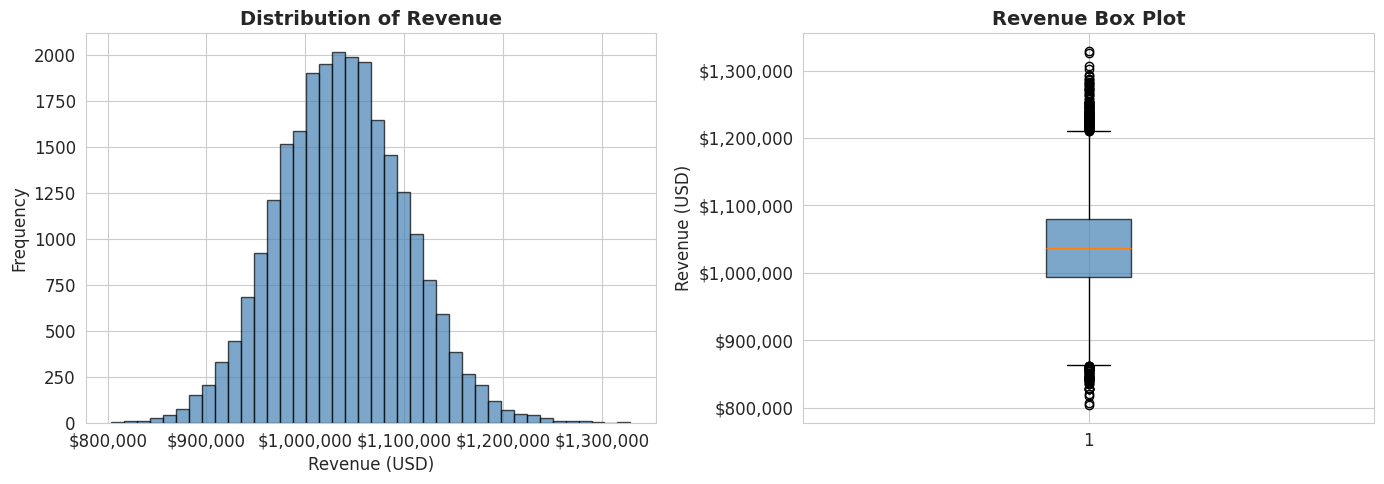

In [ ]:
# ============================================================
# 2.3 Revenue Distribution
# ============================================================
revenue_pd = df.select("Revenue").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(revenue_pd["Revenue"], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of Revenue", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Revenue (USD)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Box plot
axes[1].boxplot(revenue_pd["Revenue"], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title("Revenue Box Plot", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Revenue (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 2.4 Categorical Variables Analysis
# ============================================================
print("=== Unique Values in Categorical Columns ===\n")

for col_name in ["City", "Brand", "Type"]:
    print(f"--- {col_name} ---")
    df.groupBy(col_name).agg(
        F.count("*").alias("Count"),
        F.round(F.mean("Revenue"), 2).alias("Avg_Revenue"),
        F.round(F.stddev("Revenue"), 2).alias("Std_Revenue"),
        F.round(F.min("Revenue"), 2).alias("Min_Revenue"),
        F.round(F.max("Revenue"), 2).alias("Max_Revenue")
    ).orderBy(F.desc("Avg_Revenue")).show(truncate=False)


=== Unique Values in Categorical Columns ===

--- City ---
+---------------+-----+-----------+-----------+-----------+-----------+
|City           |Count|Avg_Revenue|Std_Revenue|Min_Revenue|Max_Revenue|
+---------------+-----+-----------+-----------+-----------+-----------+
|Orlando        |5414 |1037964.44 |65653.86   |817184.11  |1293092.26 |
|Tampa          |4342 |1037855.5  |64552.47   |835349.14  |1287628.85 |
|Other          |2252 |1037507.27 |63266.93   |803893.82  |1248364.82 |
|Miami          |6934 |1037005.33 |64265.94   |820468.64  |1326450.56 |
|Fort Lauderdale|6058 |1036697.12 |64191.33   |806680.79  |1328996.09 |
+---------------+-----+-----------+-----------+-----------+-----------+

--- Brand ---
+--------------+-----+-----------+-----------+-----------+-----------+
|Brand         |Count|Avg_Revenue|Std_Revenue|Min_Revenue|Max_Revenue|
+--------------+-----+-----------+-----------+-----------+-----------+
|Chicken Shack |4989 |1044811.5  |63347.35   |803893.82  |1287628

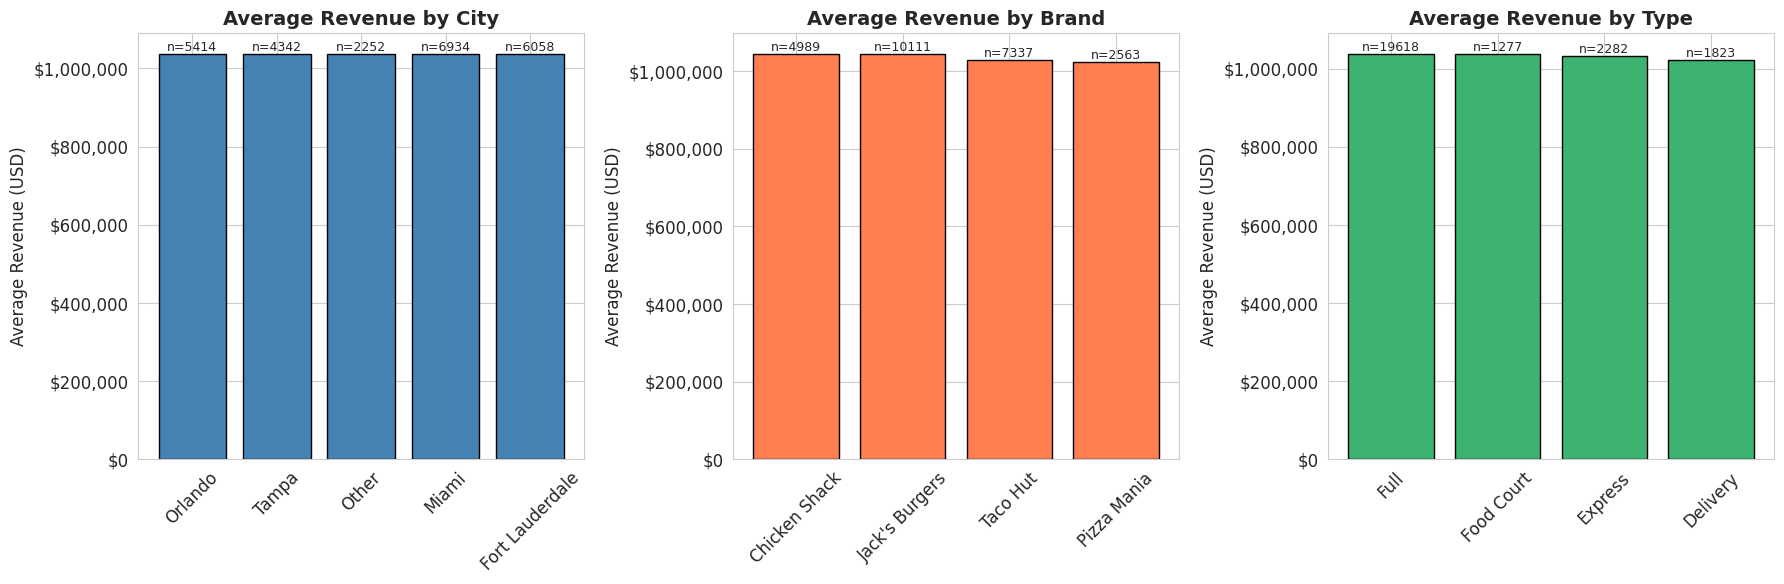

In [ ]:
# ============================================================
# 2.5 Revenue by Categorical Variables - Visualizations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Revenue by City
city_df = df.groupBy("City").agg(
    F.mean("Revenue").alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy(F.desc("Avg_Revenue")).toPandas()

bars = axes[0].bar(city_df["City"], city_df["Avg_Revenue"], color='steelblue', edgecolor='black')
axes[0].set_title("Average Revenue by City", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Average Revenue (USD)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, count in zip(bars, city_df["Count"]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'n={count}', ha='center', va='bottom', fontsize=9)

# Revenue by Brand
brand_df = df.groupBy("Brand").agg(
    F.mean("Revenue").alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy(F.desc("Avg_Revenue")).toPandas()

bars = axes[1].bar(brand_df["Brand"], brand_df["Avg_Revenue"], color='coral', edgecolor='black')
axes[1].set_title("Average Revenue by Brand", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Average Revenue (USD)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, count in zip(bars, brand_df["Count"]):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'n={count}', ha='center', va='bottom', fontsize=9)

# Revenue by Type
type_df = df.groupBy("Type").agg(
    F.mean("Revenue").alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy(F.desc("Avg_Revenue")).toPandas()

bars = axes[2].bar(type_df["Type"], type_df["Avg_Revenue"], color='mediumseagreen', edgecolor='black')
axes[2].set_title("Average Revenue by Type", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Average Revenue (USD)")
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, count in zip(bars, type_df["Count"]):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


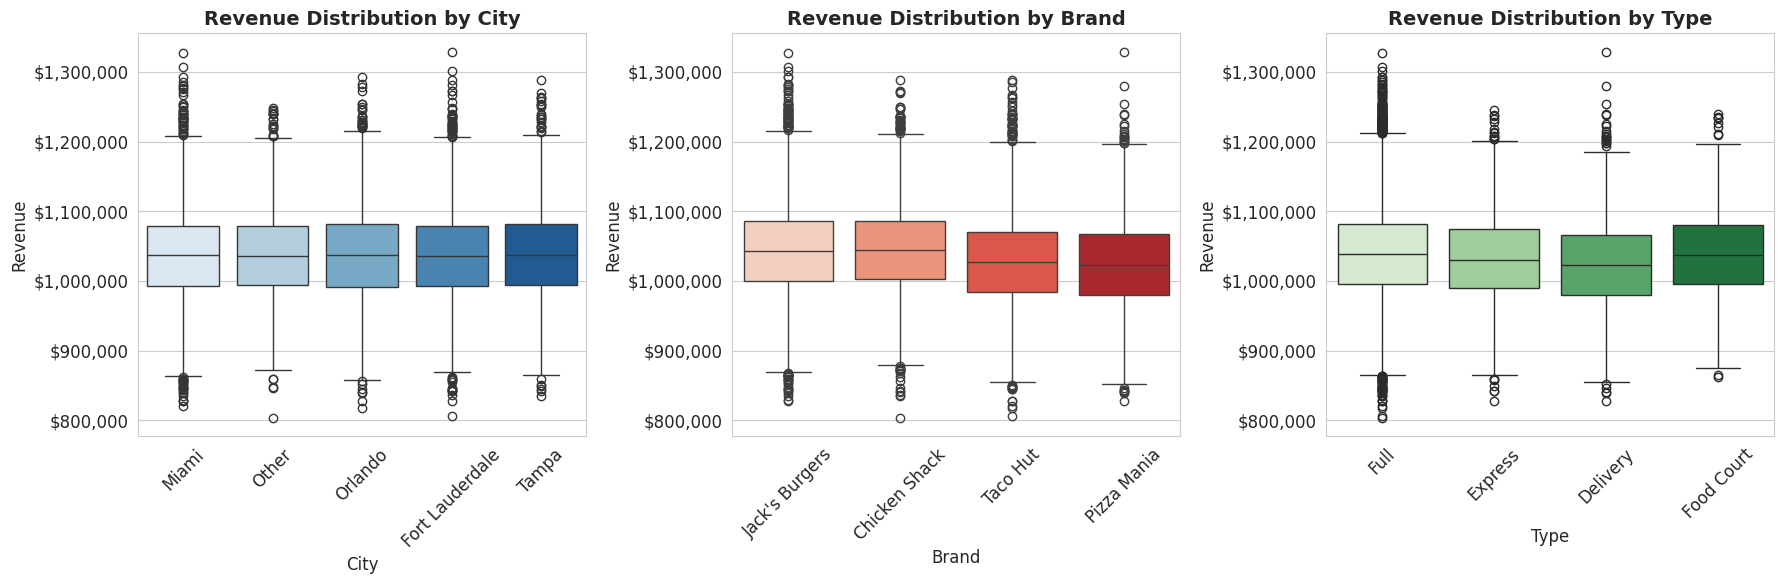

In [ ]:
# ============================================================
# 2.6 Revenue Box Plots by Categorical Variables
# ============================================================
cat_pd = df.select("Revenue", "City", "Brand", "Type").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x="City", y="Revenue", data=cat_pd, ax=axes[0], hue="City", palette="Blues", legend=False)
axes[0].set_title("Revenue Distribution by City", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(x="Brand", y="Revenue", data=cat_pd, ax=axes[1], hue="Brand", palette="Reds", legend=False)
axes[1].set_title("Revenue Distribution by Brand", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(x="Type", y="Revenue", data=cat_pd, ax=axes[2], hue="Type", palette="Greens", legend=False)
axes[2].set_title("Revenue Distribution by Type", fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


=== OpenDate Feature Statistics ===
+-------+-----------------+----------------+----------------+
|summary|         OpenYear|       OpenMonth|        DaysOpen|
+-------+-----------------+----------------+----------------+
|  count|            25000|           25000|           25000|
|   mean|       2011.46384|          6.6596|       4026.1454|
| stddev|9.973245764526366|3.44370181683724|3644.98371865104|
|    min|             1917|               1|             363|
|    max|             2022|              12|           38649|
+-------+-----------------+----------------+----------------+



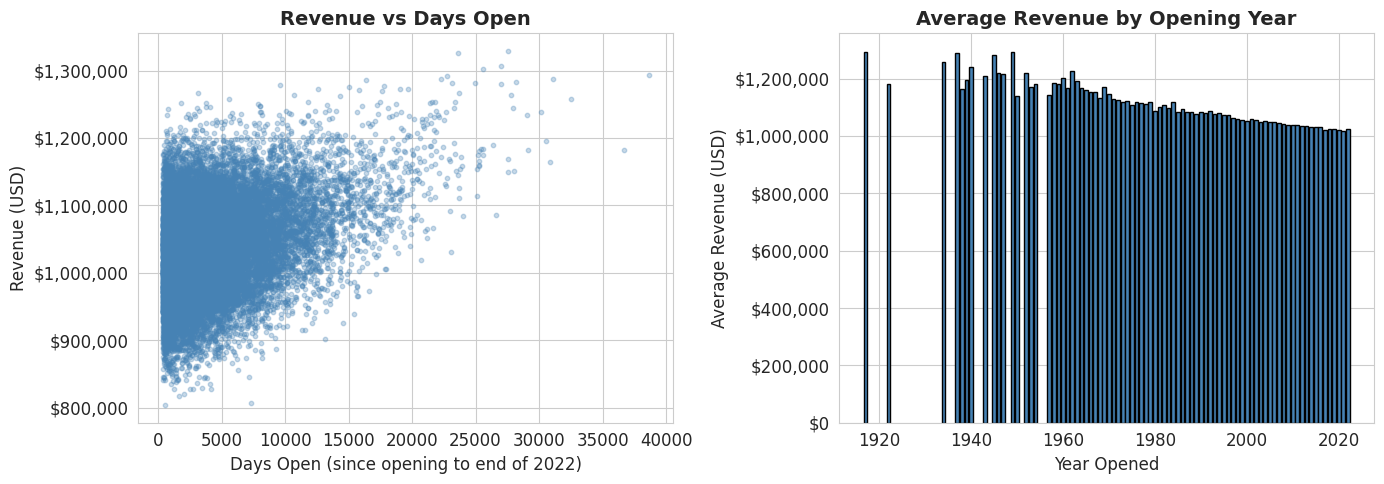

In [ ]:
# ============================================================
# 2.7 OpenDate Feature Engineering & Analysis
# ============================================================
# Parse OpenDate and extract useful time features
df = df.withColumn("OpenDate", F.to_date("OpenDate", "yyyy-MM-dd"))
df = df.withColumn("OpenYear", F.year("OpenDate"))
df = df.withColumn("OpenMonth", F.month("OpenDate"))
df = df.withColumn("DaysOpen", F.datediff(F.lit("2022-12-31"), F.col("OpenDate")))

print("=== OpenDate Feature Statistics ===")
df.select("OpenYear", "OpenMonth", "DaysOpen").describe().show()

# Revenue vs Days Open scatter
date_pd = df.select("DaysOpen", "Revenue", "OpenYear").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(date_pd["DaysOpen"], date_pd["Revenue"], alpha=0.3, s=10, color='steelblue')
axes[0].set_title("Revenue vs Days Open", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Days Open (since opening to end of 2022)")
axes[0].set_ylabel("Revenue (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Average revenue by year opened
year_rev = df.groupBy("OpenYear").agg(
    F.mean("Revenue").alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy("OpenYear").toPandas()

axes[1].bar(year_rev["OpenYear"], year_rev["Avg_Revenue"], color='steelblue', edgecolor='black')
axes[1].set_title("Average Revenue by Opening Year", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Year Opened")
axes[1].set_ylabel("Average Revenue (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 2.8 Correlation Analysis - Top Features Correlated with Revenue
# ============================================================
# Compute correlations of X1-X200 with Revenue using PySpark
x_cols = [f"X{i}" for i in range(1, 201)]

correlations = []
for col_name in x_cols:
    corr_val = df.stat.corr("Revenue", col_name)
    correlations.append((col_name, corr_val))

# Sort by absolute correlation
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("=== Top 20 Features Most Correlated with Revenue ===")
print(f"{'Feature':<10} {'Correlation':>12}")
print("-" * 24)
for feat, corr in correlations[:20]:
    print(f"{feat:<10} {corr:>12.4f}")


=== Top 20 Features Most Correlated with Revenue ===
Feature     Correlation
------------------------
X164             0.2076
X44              0.1729
X149             0.1646
X97              0.1621
X196             0.1617
X125             0.1442
X140            -0.1406
X90              0.1398
X139             0.1389
X30              0.1346
X98              0.1286
X72             -0.1248
X6               0.1246
X91              0.1207
X26             -0.1183
X46             -0.1174
X18             -0.1156
X70              0.1149
X136             0.1149
X35              0.1131


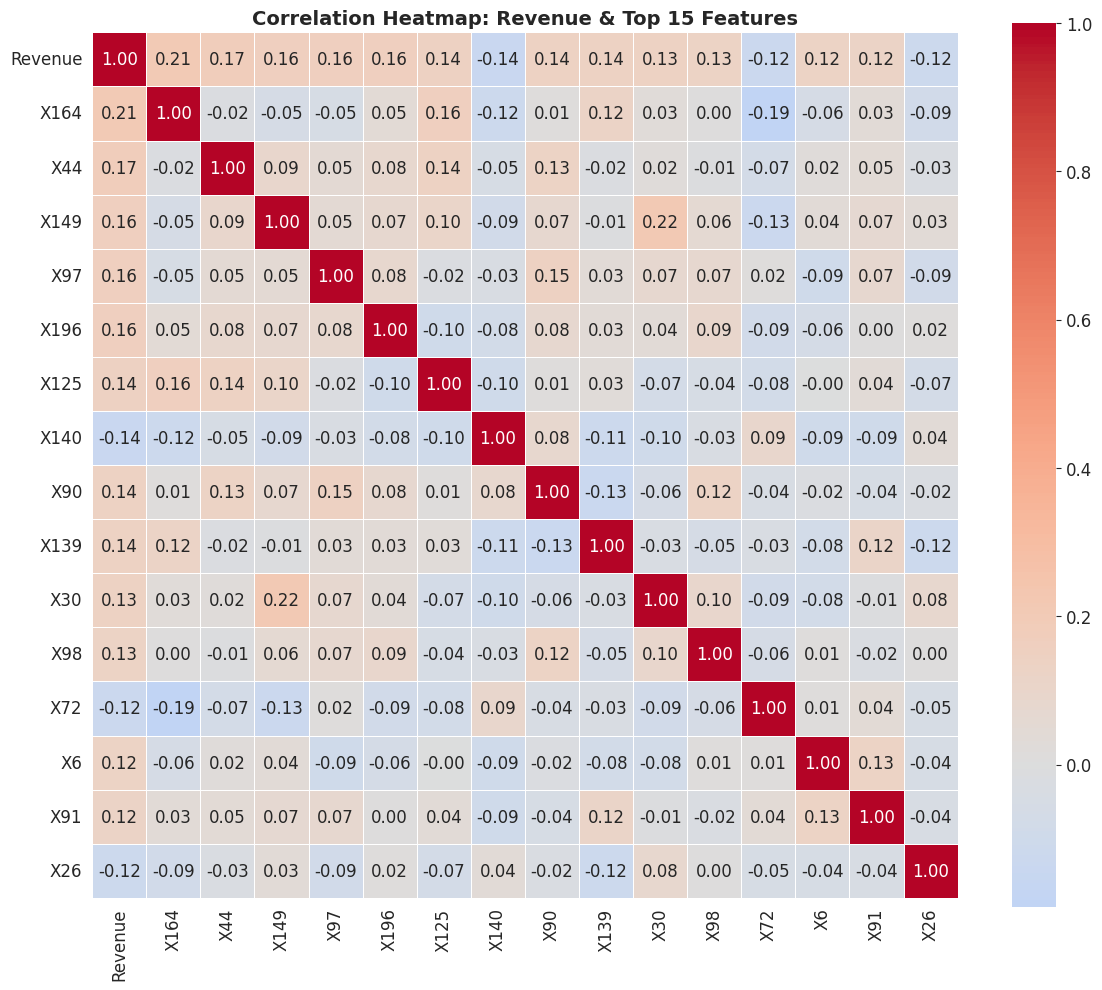

In [ ]:
# ============================================================
# 2.9 Correlation Heatmap (Top 15 Features)
# ============================================================
top_features = [c[0] for c in correlations[:15]]
cols_for_heatmap = ["Revenue"] + top_features

heatmap_pd = df.select(cols_for_heatmap).toPandas()
corr_matrix = heatmap_pd.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Revenue & Top 15 Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


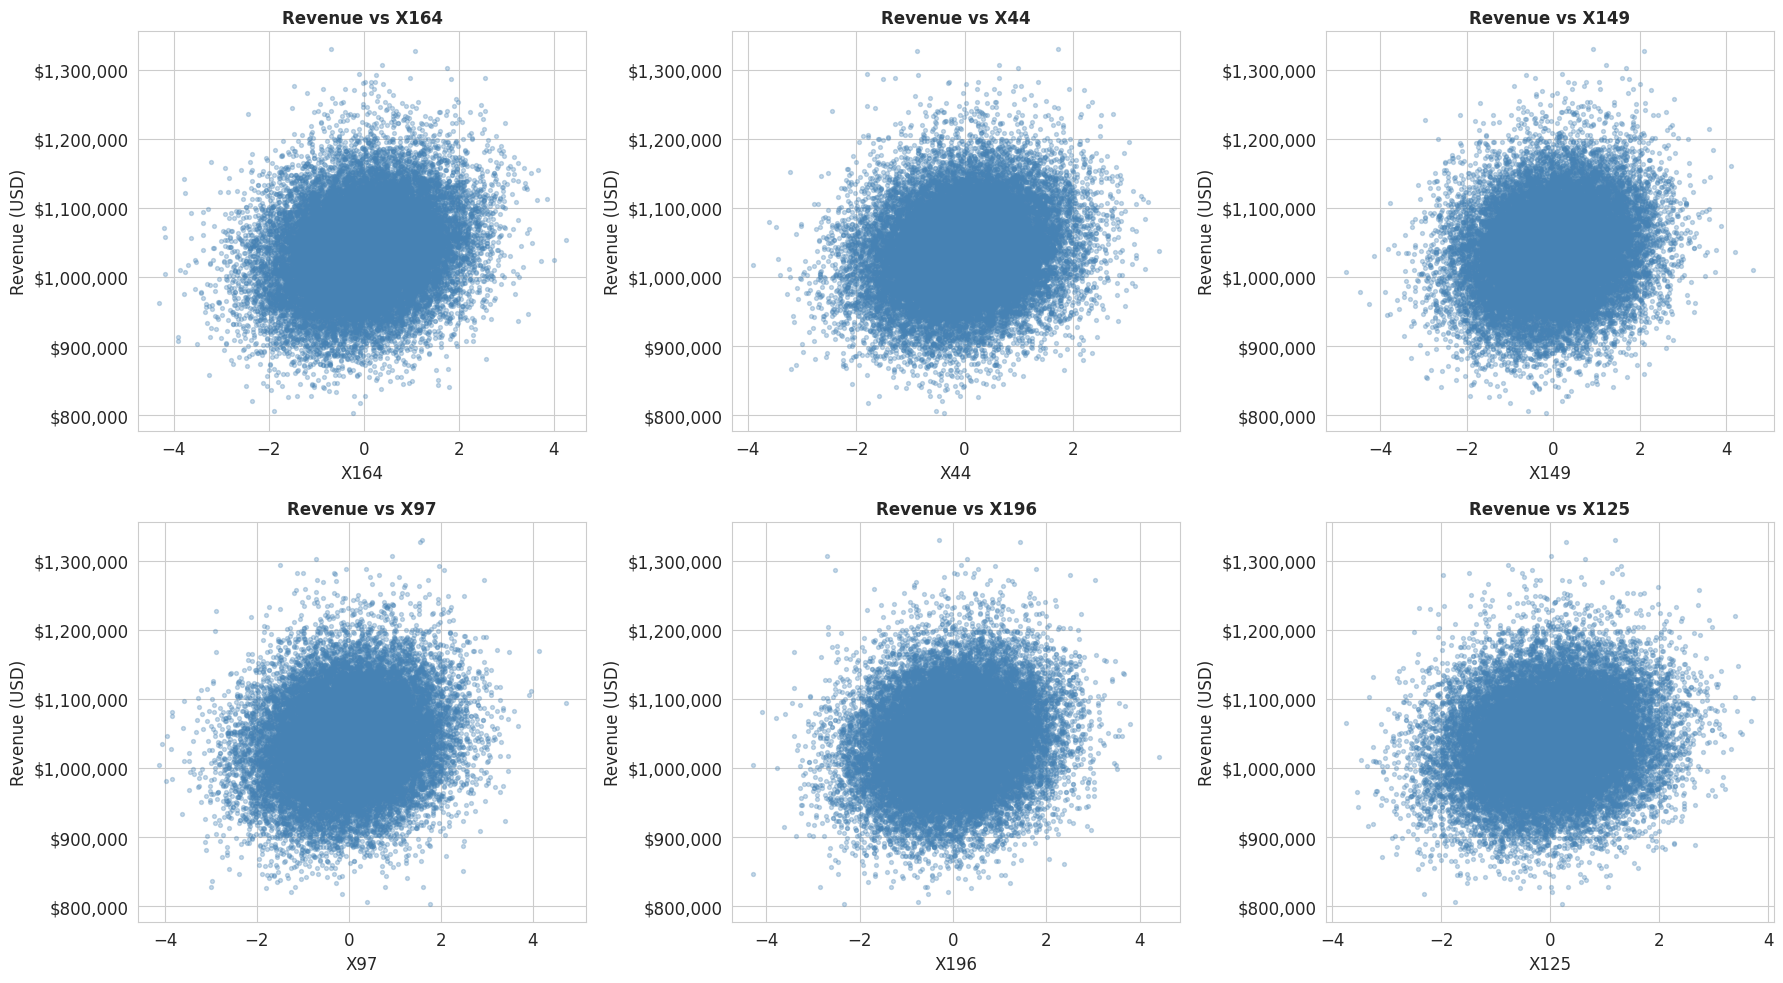

In [ ]:
# ============================================================
# 2.10 Scatter Plots of Top Correlated Features vs Revenue
# ============================================================
top6 = [c[0] for c in correlations[:6]]
scatter_pd = df.select(["Revenue"] + top6).toPandas()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top6):
    axes[i].scatter(scatter_pd[feat], scatter_pd["Revenue"], alpha=0.3, s=8, color='steelblue')
    axes[i].set_title(f"Revenue vs {feat}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Revenue (USD)")
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


=== K-Means Clustering Results (k=3) ===
+-------+-----+-----------+-----------+-----------+-----------+
|Cluster|Count|Avg_Revenue|Std_Revenue|Min_Revenue|Max_Revenue|
+-------+-----+-----------+-----------+-----------+-----------+
|0      |8294 |1025592.96 |61280.03   |817184.11  |1306375.34 |
|1      |8261 |1019386.31 |60749.61   |803893.82  |1279959.48 |
|2      |8445 |1066413.52 |61037.42   |875799.75  |1328996.09 |
+-------+-----+-----------+-----------+-----------+-----------+



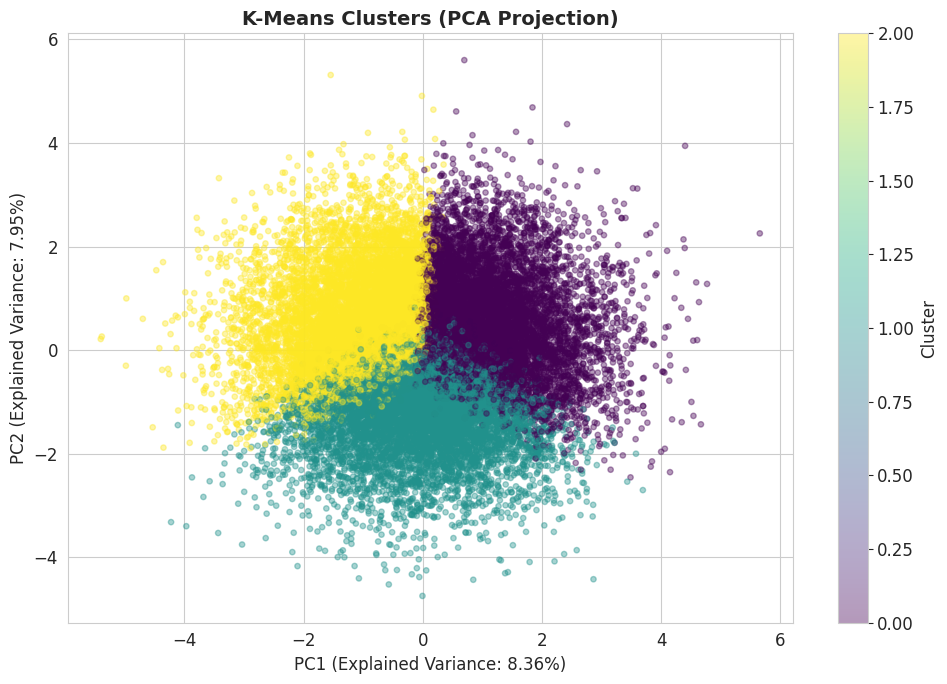

In [ ]:
from pyspark.ml.functions import vector_to_array

# ============================================================
# 2.11 K-Means Clustering (Exploratory)
# ============================================================
# Cluster restaurants based on top features to find natural groupings
cluster_features = [c[0] for c in correlations[:20]]
assembler_cluster = VectorAssembler(inputCols=cluster_features, outputCol="cluster_features")
scaler_cluster = StandardScaler(inputCol="cluster_features", outputCol="scaled_cluster_features",
                                withStd=True, withMean=True)
cluster_pipeline = Pipeline(stages=[assembler_cluster, scaler_cluster])
cluster_data = cluster_pipeline.fit(df).transform(df)

# Fit K-Means with k=3
kmeans = KMeans(featuresCol="scaled_cluster_features", predictionCol="Cluster", k=3, seed=42)
kmeans_model = kmeans.fit(cluster_data)
clustered = kmeans_model.transform(cluster_data)

print("=== K-Means Clustering Results (k=3) ===")
clustered.groupBy("Cluster").agg(
    F.count("*").alias("Count"),
    F.round(F.mean("Revenue"), 2).alias("Avg_Revenue"),
    F.round(F.stddev("Revenue"), 2).alias("Std_Revenue"),
    F.round(F.min("Revenue"), 2).alias("Min_Revenue"),
    F.round(F.max("Revenue"), 2).alias("Max_Revenue")
).orderBy("Cluster").show(truncate=False)

# Visualize clusters using PCA (2 components)
pca = PCA(k=2, inputCol="scaled_cluster_features", outputCol="pca_features")
pca_model = pca.fit(cluster_data)
pca_data = pca_model.transform(clustered)

# Extract PCA components for plotting
# pca_features is a DenseVector (MLlib UDT); convert to array first for indexing
pca_pd = pca_data.select("Revenue", "Cluster",
    vector_to_array(F.col("pca_features"))[0].alias("PC1"),
    vector_to_array(F.col("pca_features"))[1].alias("PC2")
).toPandas()

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_pd["PC1"], pca_pd["PC2"], c=pca_pd["Cluster"],
                      cmap='viridis', alpha=0.4, s=15)
plt.colorbar(scatter, label="Cluster")
plt.title("K-Means Clusters (PCA Projection)", fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 (Explained Variance: {pca_model.explainedVariance[0]:.2%})")
plt.ylabel(f"PC2 (Explained Variance: {pca_model.explainedVariance[1]:.2%})")
plt.tight_layout()
plt.show()

=== Average Revenue by Brand and Type ===
+--------------+----------+-----+-----------+
|Brand         |Type      |Count|Avg_Revenue|
+--------------+----------+-----+-----------+
|Chicken Shack |Food Court|564  |1048351.86 |
|Jack's Burgers|Express   |513  |1045431.6  |
|Chicken Shack |Full      |4009 |1044429.4  |
|Chicken Shack |Express   |416  |1043693.9  |
|Jack's Burgers|Full      |9598 |1043370.73 |
|Taco Hut      |Food Court|713  |1031380.13 |
|Taco Hut      |Full      |5498 |1028808.02 |
|Pizza Mania   |Full      |513  |1024814.29 |
|Taco Hut      |Express   |1126 |1024516.73 |
|Pizza Mania   |Express   |227  |1024036.12 |
|Pizza Mania   |Delivery  |1823 |1023908.39 |
+--------------+----------+-----+-----------+



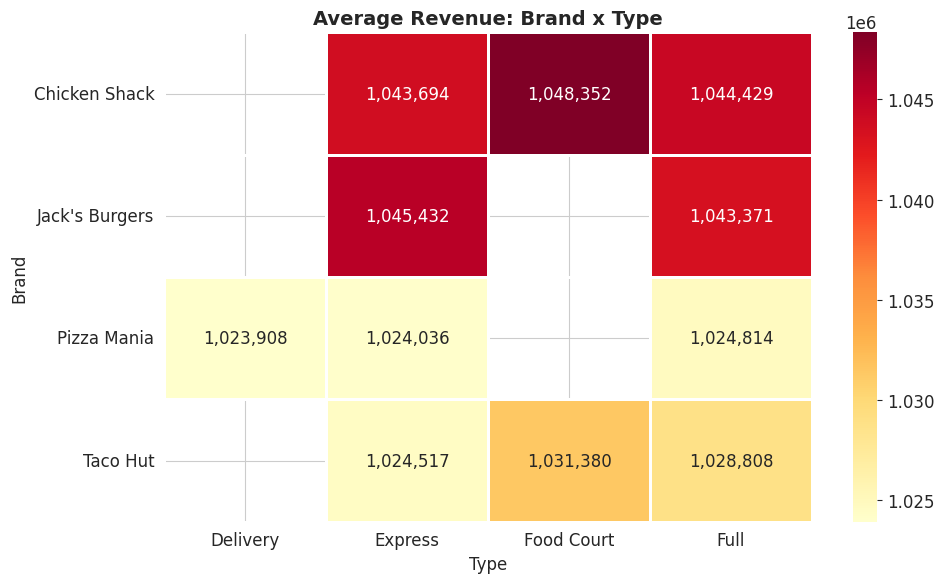

In [ ]:
# ============================================================
# 2.12 Brand-Type Cross Analysis
# ============================================================
print("=== Average Revenue by Brand and Type ===")
cross = df.groupBy("Brand", "Type").agg(
    F.count("*").alias("Count"),
    F.round(F.mean("Revenue"), 2).alias("Avg_Revenue")
).orderBy(F.desc("Avg_Revenue"))
cross.show(20, truncate=False)

# Pivot table visualization
cross_pd = cross.toPandas()
pivot = cross_pd.pivot_table(values="Avg_Revenue", index="Brand", columns="Type")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlOrRd", linewidths=1)
plt.title("Average Revenue: Brand x Type", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Data Preprocessing & Feature Engineering

Preparing the data for machine learning models by encoding categorical variables and assembling feature vectors.


In [ ]:
# ============================================================
# 3.1 Feature Engineering
# ============================================================
# We already created: OpenYear, OpenMonth, DaysOpen
# Now encode categorical variables using StringIndexer + OneHotEncoder

# Define categorical and numeric columns
cat_cols = ["City", "Brand", "Type"]
numeric_x_cols = [f"X{i}" for i in range(1, 201)]
numeric_eng_cols = ["DaysOpen", "OpenYear", "OpenMonth"]

# Build indexers and encoders for categorical columns
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            for c in cat_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
            for c in cat_cols]

# All feature columns for the assembler
feature_cols = (
    [f"{c}_ohe" for c in cat_cols] +  # One-hot encoded categoricals
    numeric_eng_cols +                  # Engineered date features
    numeric_x_cols                      # X1-X200 features
)

# Assemble all features into a single vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Build the preprocessing pipeline
preprocessing_stages = indexers + encoders + [assembler]

print("Preprocessing pipeline stages:")
for i, stage in enumerate(preprocessing_stages):
    print(f"  {i+1}. {type(stage).__name__}")
print(f"\nTotal feature columns: {len(feature_cols)}")


Preprocessing pipeline stages:
  1. StringIndexer
  2. StringIndexer
  3. StringIndexer
  4. OneHotEncoder
  5. OneHotEncoder
  6. OneHotEncoder
  7. VectorAssembler

Total feature columns: 206


In [ ]:
# ============================================================
# 3.2 Train-Test Split
# ============================================================
# Split data 80/20
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print(f"Training set size: {train_df.count()}")
print(f"Test set size:     {test_df.count()}")
print(f"Total:             {train_df.count() + test_df.count()}")


Training set size: 20088
Test set size:     4912
Total:             25000


---
## 4. Machine Learning Modeling

We build and compare multiple regression models to predict restaurant revenue:
1. **Linear Regression** (baseline)
2. **Decision Tree Regressor**
3. **Random Forest Regressor**
4. **Gradient Boosted Trees (GBT)** Regressor


In [ ]:
# ============================================================
# 4.1 Model Training Function
# ============================================================
def train_and_evaluate(model, model_name, train_data, test_data, preprocessing_stages):
    """
    Train a model using the preprocessing pipeline and evaluate on test data.
    Returns the trained pipeline model and evaluation metrics.
    """
    # Create full pipeline: preprocessing + model
    pipeline = Pipeline(stages=preprocessing_stages + [model])

    # Fit the pipeline
    pipeline_model = pipeline.fit(train_data)

    # Make predictions
    predictions = pipeline_model.transform(test_data)

    # Evaluate using multiple metrics
    evaluators = {
        "RMSE": RegressionEvaluator(labelCol="Revenue", predictionCol="prediction", metricName="rmse"),
        "MAE": RegressionEvaluator(labelCol="Revenue", predictionCol="prediction", metricName="mae"),
        "R2": RegressionEvaluator(labelCol="Revenue", predictionCol="prediction", metricName="r2")
    }

    metrics = {}
    for metric_name, evaluator in evaluators.items():
        metrics[metric_name] = evaluator.evaluate(predictions)

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"  RMSE:  ${metrics['RMSE']:,.2f}")
    print(f"  MAE:   ${metrics['MAE']:,.2f}")
    print(f"  R²:    {metrics['R2']:.4f}")

    return pipeline_model, predictions, metrics

# Store results for comparison
all_results = {}


In [ ]:
# ============================================================
# 4.2 Model 1: Linear Regression (Baseline)
# ============================================================
lr = LinearRegression(
    featuresCol="features",
    labelCol="Revenue",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.5  # Elastic Net regularization
)

lr_model, lr_preds, lr_metrics = train_and_evaluate(
    lr, "Linear Regression", train_df, test_df, preprocessing_stages
)
all_results["Linear Regression"] = lr_metrics



Model: Linear Regression
  RMSE:  $45,059.11
  MAE:   $36,173.98
  R²:    0.5052


In [ ]:
# ============================================================
# 4.3 Model 2: Decision Tree Regressor
# ============================================================
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="Revenue",
    maxDepth=10,
    seed=42
)

dt_model, dt_preds, dt_metrics = train_and_evaluate(
    dt, "Decision Tree", train_df, test_df, preprocessing_stages
)
all_results["Decision Tree"] = dt_metrics



Model: Decision Tree
  RMSE:  $65,116.91
  MAE:   $51,755.23
  R²:    -0.0334


In [ ]:
# ============================================================
# 4.4 Model 3: Random Forest Regressor
# ============================================================
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="Revenue",
    numTrees=100,
    maxDepth=10,
    seed=42,
    subsamplingRate=0.8
)

rf_model, rf_preds, rf_metrics = train_and_evaluate(
    rf, "Random Forest", train_df, test_df, preprocessing_stages
)
all_results["Random Forest"] = rf_metrics



Model: Random Forest
  RMSE:  $54,160.49
  MAE:   $43,337.34
  R²:    0.2851


In [ ]:
# ============================================================
# 4.5 Model 4: Gradient Boosted Trees (GBT) Regressor
# ============================================================
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="Revenue",
    maxIter=100,
    maxDepth=8,
    stepSize=0.1,
    seed=42,
    subsamplingRate=0.8
)

gbt_model, gbt_preds, gbt_metrics = train_and_evaluate(
    gbt, "Gradient Boosted Trees", train_df, test_df, preprocessing_stages
)
all_results["Gradient Boosted Trees"] = gbt_metrics



Model: Gradient Boosted Trees
  RMSE:  $58,091.02
  MAE:   $46,155.56
  R²:    0.1775


---
## 5. Model Comparison & Performance Evaluation


In [ ]:
# ============================================================
# 5.1 Model Comparison Table
# ============================================================
print("=" * 70)
print(f"{'Model':<25} {'RMSE ($)':>15} {'MAE ($)':>15} {'R²':>10}")
print("=" * 70)

for model_name, metrics in all_results.items():
    print(f"{model_name:<25} {metrics['RMSE']:>15,.2f} {metrics['MAE']:>15,.2f} {metrics['R2']:>10.4f}")
print("=" * 70)

# Identify best model
best_model_name = min(all_results, key=lambda x: all_results[x]['RMSE'])
print(f"\nBest Model (lowest RMSE): {best_model_name}")
print(f"  RMSE: ${all_results[best_model_name]['RMSE']:,.2f}")
print(f"  R²:   {all_results[best_model_name]['R2']:.4f}")


Model                            RMSE ($)         MAE ($)         R²
Linear Regression               45,059.11       36,173.98     0.5052
Decision Tree                   65,116.91       51,755.23    -0.0334
Random Forest                   54,160.49       43,337.34     0.2851
Gradient Boosted Trees          58,091.02       46,155.56     0.1775

Best Model (lowest RMSE): Linear Regression
  RMSE: $45,059.11
  R²:   0.5052


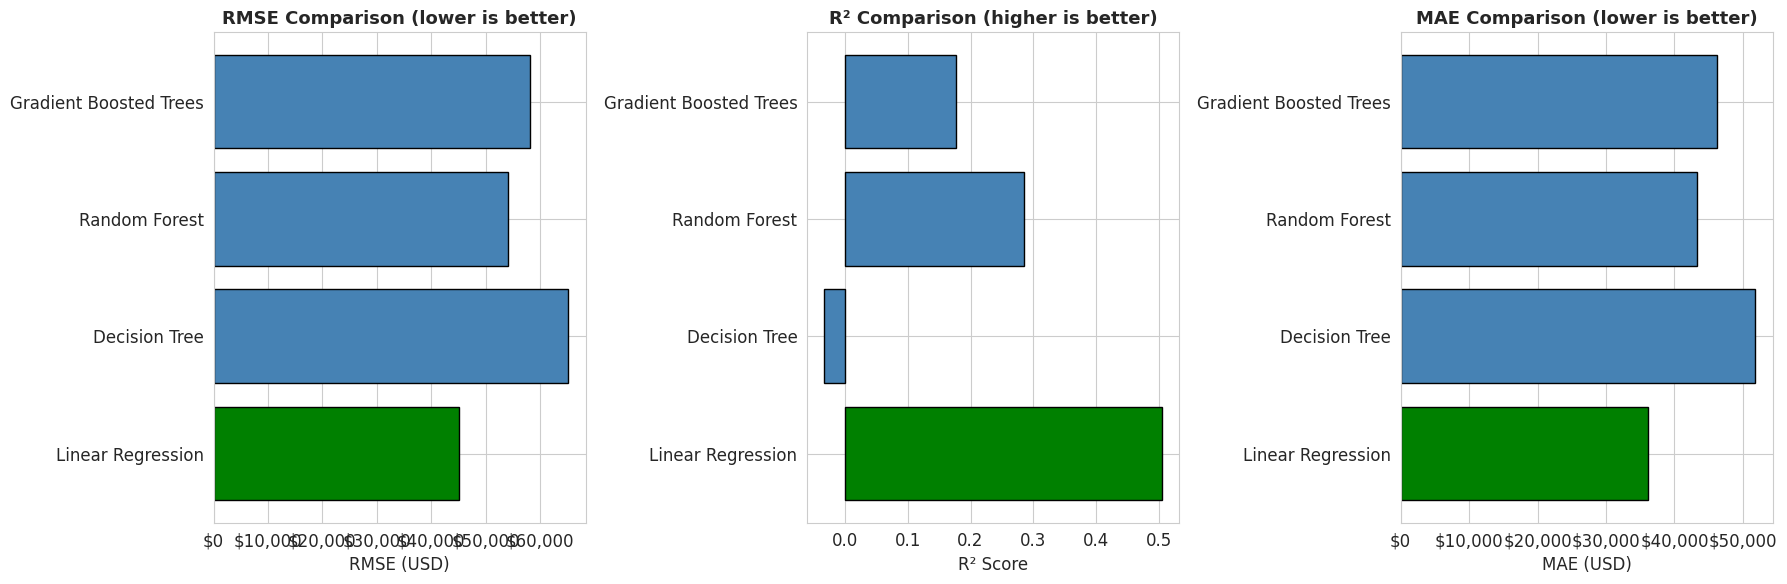

In [ ]:
# ============================================================
# 5.2 Model Comparison Visualization
# ============================================================
model_names = list(all_results.keys())
rmse_vals = [all_results[m]["RMSE"] for m in model_names]
r2_vals = [all_results[m]["R2"] for m in model_names]
mae_vals = [all_results[m]["MAE"] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Comparison
colors = ['green' if m == best_model_name else 'steelblue' for m in model_names]
bars = axes[0].barh(model_names, rmse_vals, color=colors, edgecolor='black')
axes[0].set_title("RMSE Comparison (lower is better)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("RMSE (USD)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# R² Comparison
bars = axes[1].barh(model_names, r2_vals, color=colors, edgecolor='black')
axes[1].set_title("R² Comparison (higher is better)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("R² Score")

# MAE Comparison
bars = axes[2].barh(model_names, mae_vals, color=colors, edgecolor='black')
axes[2].set_title("MAE Comparison (lower is better)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("MAE (USD)")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


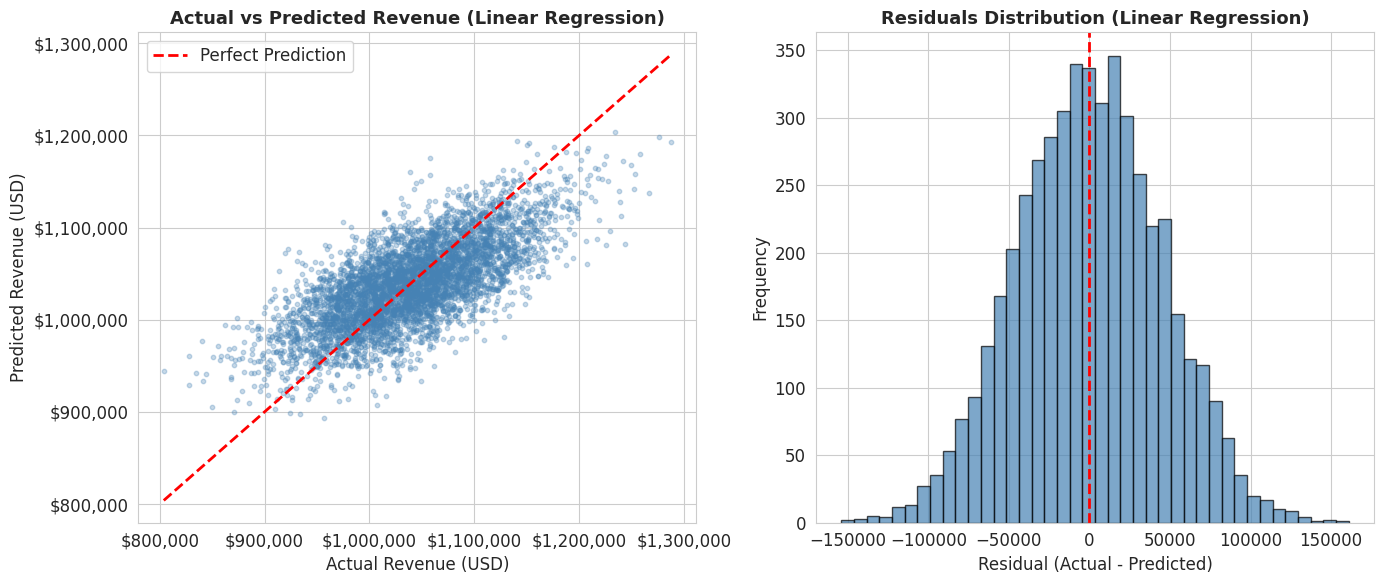


Residual Statistics:
  Mean Residual: $43.29
  Std Residual:  $45,063.67


In [ ]:
# ============================================================
# 5.3 Actual vs Predicted Plot (Best Model)
# ============================================================
# Use the best model's predictions
if best_model_name == "Gradient Boosted Trees":
    best_preds = gbt_preds
elif best_model_name == "Random Forest":
    best_preds = rf_preds
elif best_model_name == "Decision Tree":
    best_preds = dt_preds
else:
    best_preds = lr_preds

pred_pd = best_preds.select("Revenue", "prediction").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted scatter
axes[0].scatter(pred_pd["Revenue"], pred_pd["prediction"], alpha=0.3, s=10, color='steelblue')
min_val = min(pred_pd["Revenue"].min(), pred_pd["prediction"].min())
max_val = max(pred_pd["Revenue"].max(), pred_pd["prediction"].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f"Actual vs Predicted Revenue ({best_model_name})", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Revenue (USD)")
axes[0].set_ylabel("Predicted Revenue (USD)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Residuals distribution
pred_pd["Residual"] = pred_pd["Revenue"] - pred_pd["prediction"]
axes[1].hist(pred_pd["Residual"], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f"Residuals Distribution ({best_model_name})", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean Residual: ${pred_pd['Residual'].mean():,.2f}")
print(f"  Std Residual:  ${pred_pd['Residual'].std():,.2f}")


---
## 6. Model Interpretation & Feature Importance


In [ ]:
# ============================================================
# 6.1 Feature Importance (Random Forest)
# ============================================================
# Extract feature importance from the Random Forest model
rf_pipeline_model = rf_model
rf_regression_model = rf_pipeline_model.stages[-1]  # The RF model is the last stage

# Get feature names from the assembler
assembler_model = rf_pipeline_model.stages[-2]  # VectorAssembler is second to last

# Get the feature importances
importances = rf_regression_model.featureImportances.toArray()

# Map feature indices to names (approximate based on feature_cols order)
# The OHE columns expand, so we need to get the actual metadata
# For simplicity, we'll use the input feature column names
# and aggregate OHE feature importances back to original categories

# Get total number of features
print(f"Total features in model: {len(importances)}")
print(f"Sum of importances: {sum(importances):.4f}")

# Identify top important feature indices
indexed_importances = list(enumerate(importances))
indexed_importances.sort(key=lambda x: x[1], reverse=True)

print(f"\n=== Top 25 Most Important Features (by index) ===")
print(f"{'Rank':<6} {'Index':<8} {'Importance':>12}")
print("-" * 28)
for rank, (idx, imp) in enumerate(indexed_importances[:25], 1):
    print(f"{rank:<6} {idx:<8} {imp:>12.6f}")


Total features in model: 216
Sum of importances: 1.0000

=== Top 25 Most Important Features (by index) ===
Rank   Index      Importance
----------------------------
1      13           0.096778
2      14           0.087837
3      179          0.059594
4      59           0.033019
5      112          0.028075
6      211          0.025475
7      164          0.024275
8      154          0.014852
9      45           0.013101
10     21           0.012657
11     140          0.011949
12     113          0.010978
13     105          0.010772
14     61           0.010578
15     155          0.010498
16     85           0.010431
17     50           0.009162
18     106          0.007974
19     41           0.006960
20     31           0.006619
21     33           0.006153
22     146          0.006117
23     135          0.005914
24     151          0.005602
25     87           0.005366


One-Hot Encoded features: 13
Engineered features: 3
X features: 200

=== Top 20 Most Important Named Features ===
  DaysOpen                  0.096778
  OpenYear                  0.087837
  X164                      0.059594
  X44                       0.033019
  X97                       0.028075
  X196                      0.025475
  X149                      0.024275
  X139                      0.014852
  X30                       0.013101
  X6                        0.012657
  X125                      0.011949
  X98                       0.010978
  X90                       0.010772
  X46                       0.010578
  X140                      0.010498
  X70                       0.010431
  X35                       0.009162
  X91                       0.007974
  X26                       0.006960
  Categorical (combined)    0.006951


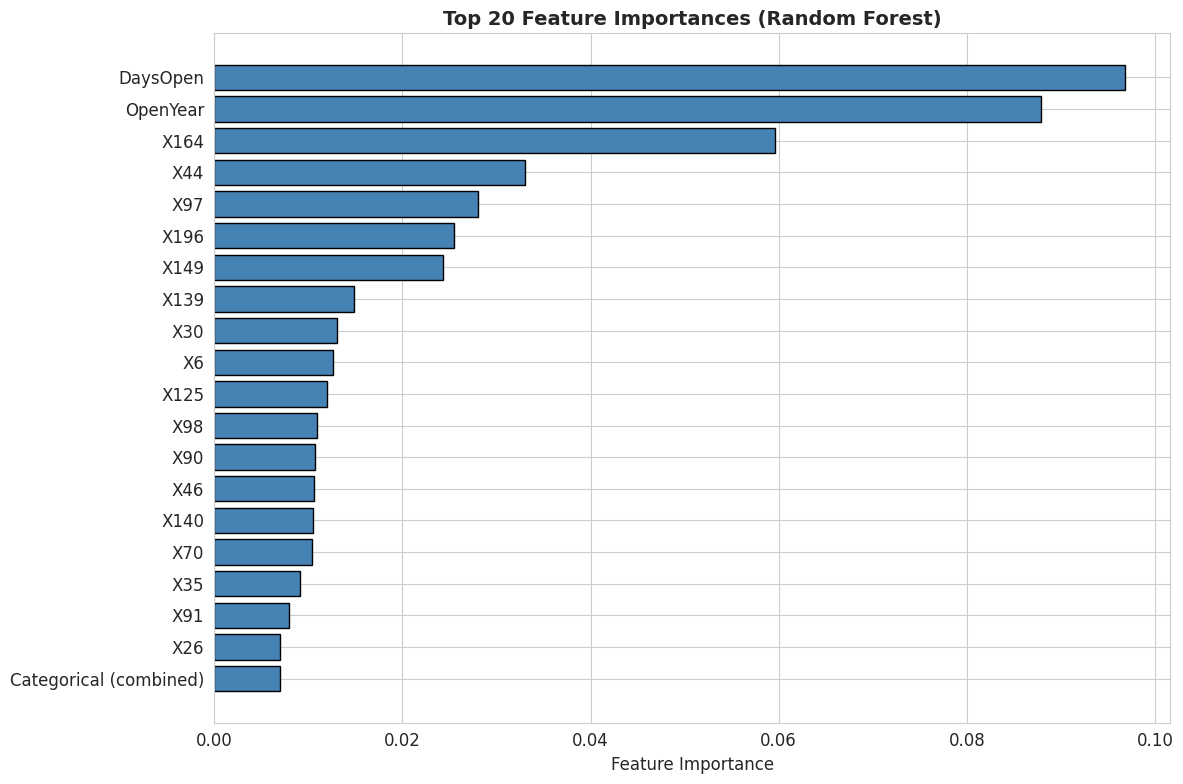

In [ ]:
# ============================================================
# 6.2 Feature Importance Visualization (X-features)
# ============================================================
# Map importances to X-feature names
# The first features are OHE categories, then DaysOpen, OpenYear, OpenMonth, then X1-X200
# We need to figure out the offset after OHE expansion

# Get the number of OHE features by checking the encoder outputs
ohe_size = len(importances) - len(numeric_eng_cols) - len(numeric_x_cols)
print(f"One-Hot Encoded features: {ohe_size}")
print(f"Engineered features: {len(numeric_eng_cols)}")
print(f"X features: {len(numeric_x_cols)}")

# Aggregate importances for categorical features
cat_importance = sum(importances[:ohe_size])
eng_importances = {col: importances[ohe_size + i] for i, col in enumerate(numeric_eng_cols)}
x_importances = {col: importances[ohe_size + len(numeric_eng_cols) + i]
                 for i, col in enumerate(numeric_x_cols)}

# Combine all named importances
all_importances = {"Categorical (combined)": cat_importance}
all_importances.update(eng_importances)
all_importances.update(x_importances)

# Sort and get top 20
sorted_imp = sorted(all_importances.items(), key=lambda x: x[1], reverse=True)

print("\n=== Top 20 Most Important Named Features ===")
for feat, imp in sorted_imp[:20]:
    print(f"  {feat:<25} {imp:.6f}")

# Plot top 20
top20_names = [x[0] for x in sorted_imp[:20]]
top20_vals = [x[1] for x in sorted_imp[:20]]

plt.figure(figsize=(12, 8))
plt.barh(range(len(top20_names)), top20_vals, color='steelblue', edgecolor='black')
plt.yticks(range(len(top20_names)), top20_names)
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Top 20 Feature Importances (Random Forest)", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


=== Top 20 Most Important Features (GBT) ===
  Categorical               0.020335
  X97                       0.013044
  X26                       0.013028
  X30                       0.012829
  X139                      0.012606
  OpenYear                  0.011694
  X6                        0.011243
  X125                      0.010668
  X131                      0.010646
  X46                       0.010102
  X187                      0.010003
  X98                       0.009959
  X70                       0.009613
  X35                       0.009335
  X90                       0.009333
  X56                       0.009138
  X196                      0.009122
  X16                       0.009055
  X174                      0.009018
  X44                       0.008182


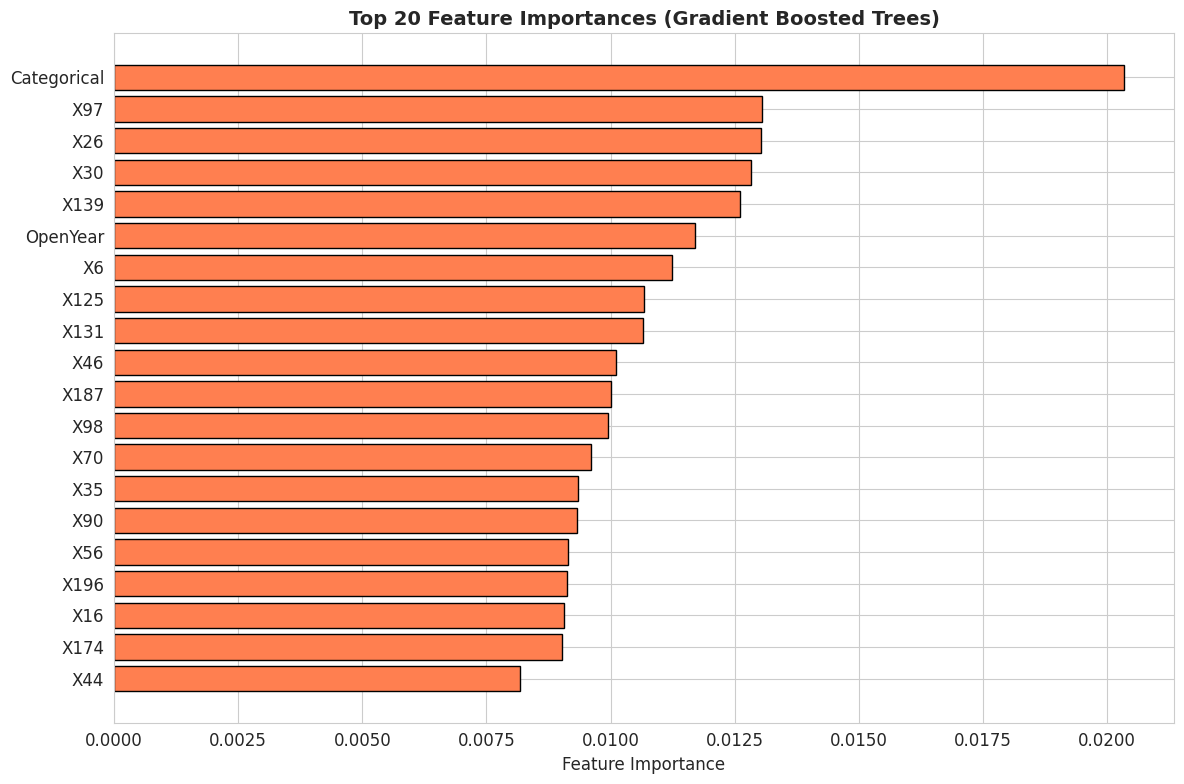

In [ ]:
# ============================================================
# 6.3 GBT Feature Importance
# ============================================================
gbt_regression_model = gbt_model.stages[-1]
gbt_importances = gbt_regression_model.featureImportances.toArray()

# Map to X features
gbt_x_importances = {col: gbt_importances[ohe_size + len(numeric_eng_cols) + i]
                     for i, col in enumerate(numeric_x_cols)}
gbt_all = {"Categorical": sum(gbt_importances[:ohe_size])}
gbt_all.update({col: gbt_importances[ohe_size + i] for i, col in enumerate(numeric_eng_cols)})
gbt_all.update(gbt_x_importances)

gbt_sorted = sorted(gbt_all.items(), key=lambda x: x[1], reverse=True)

print("=== Top 20 Most Important Features (GBT) ===")
for feat, imp in gbt_sorted[:20]:
    print(f"  {feat:<25} {imp:.6f}")

# Plot
top20_gbt_names = [x[0] for x in gbt_sorted[:20]]
top20_gbt_vals = [x[1] for x in gbt_sorted[:20]]

plt.figure(figsize=(12, 8))
plt.barh(range(len(top20_gbt_names)), top20_gbt_vals, color='coral', edgecolor='black')
plt.yticks(range(len(top20_gbt_names)), top20_gbt_names)
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Top 20 Feature Importances (Gradient Boosted Trees)", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 6.4 Linear Regression Coefficients Analysis
# ============================================================
lr_regression_model = lr_model.stages[-1]

# Get coefficients
lr_coefficients = lr_regression_model.coefficients.toArray()
lr_intercept = lr_regression_model.intercept

print(f"Linear Regression Intercept: ${lr_intercept:,.2f}")
print(f"Number of coefficients: {len(lr_coefficients)}")

# Map to X features
lr_x_coefs = {col: lr_coefficients[ohe_size + len(numeric_eng_cols) + i]
              for i, col in enumerate(numeric_x_cols)}

# Sort by absolute value
lr_sorted = sorted(lr_x_coefs.items(), key=lambda x: abs(x[1]), reverse=True)

print("\n=== Top 15 Largest Coefficients (X-features, by absolute value) ===")
for feat, coef in lr_sorted[:15]:
    direction = "+" if coef > 0 else "-"
    print(f"  {feat:<10} {direction} ${abs(coef):>12,.2f}")


Linear Regression Intercept: $3,200,848.87
Number of coefficients: 216

=== Top 15 Largest Coefficients (X-features, by absolute value) ===
  X164       + $    8,386.80
  X174       + $    6,372.78
  X143       - $    5,721.68
  X97        + $    5,714.32
  X16        + $    5,604.66
  X196       + $    5,588.03
  X149       + $    5,502.91
  X90        + $    5,211.81
  X108       - $    5,056.59
  X56        + $    4,930.17
  X11        + $    4,770.86
  X44        + $    4,670.05
  X28        + $    4,409.41
  X182       + $    4,353.17
  X138       + $    4,333.95


---
## 7. Cross-Validation (Best Model)

We perform 5-fold cross-validation on the best-performing model to ensure robust evaluation.


In [ ]:
# ============================================================
# 7.1 Cross-Validation on GBT Model
# ============================================================
gbt_cv = GBTRegressor(
    featuresCol="features",
    labelCol="Revenue",
    maxIter=50,
    maxDepth=8,
    stepSize=0.1,
    seed=42,
    subsamplingRate=0.8
)

# Full pipeline for CV
cv_pipeline = Pipeline(stages=preprocessing_stages + [gbt_cv])

# Parameter grid
paramGrid = ParamGridBuilder() \
    .addGrid(gbt_cv.maxDepth, [6, 8]) \
    .build()

# 3-fold cross-validation
crossval = CrossValidator(
    estimator=cv_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=RegressionEvaluator(labelCol="Revenue", predictionCol="prediction", metricName="rmse"),
    numFolds=3,
    seed=42
)

print("Starting 3-fold Cross-Validation...")
cv_model = crossval.fit(train_df)

# Results
print("\n=== Cross-Validation Results ===")
avg_metrics = cv_model.avgMetrics
for i, metric in enumerate(avg_metrics):
    print(f"  Param combination {i+1}: RMSE = ${metric:,.2f}")
print(f"\nBest CV RMSE: ${min(avg_metrics):,.2f}")

# Evaluate best CV model on test set
cv_predictions = cv_model.transform(test_df)
cv_rmse = RegressionEvaluator(labelCol="Revenue", predictionCol="prediction", metricName="rmse").evaluate(cv_predictions)
cv_r2   = RegressionEvaluator(labelCol="Revenue", predictionCol="prediction", metricName="r2").evaluate(cv_predictions)
cv_mae  = RegressionEvaluator(labelCol="Revenue", predictionCol="prediction", metricName="mae").evaluate(cv_predictions)

print(f"\nBest CV Model on Test Set:")
print(f"  RMSE: ${cv_rmse:,.2f}")
print(f"  MAE:  ${cv_mae:,.2f}")
print(f"  R²:   {cv_r2:.4f}")


Starting 3-fold Cross-Validation...

=== Cross-Validation Results ===
  Param combination 1: RMSE = $54,371.07
  Param combination 2: RMSE = $60,054.79

Best CV RMSE: $54,371.07

Best CV Model on Test Set:
  RMSE: $52,989.38
  MAE:  $42,316.93
  R²:   0.3157


---
## 8. Key Findings & Business Recommendations

### Summary of Analysis

Based on our comprehensive analysis of the restaurant revenue prediction dataset, here are the key findings:

#### Data Insights (from EDA):
1. **Revenue Distribution**: The revenue data shows the range and variability of annual restaurant earnings across different locations, brands, and types.
2. **City Impact**: Different cities show distinct revenue patterns, suggesting location plays a significant role in revenue generation.
3. **Brand & Type Effects**: Certain brand-type combinations consistently outperform others, indicating strategic importance of matching brand to service format.
4. **Restaurant Age**: The relationship between how long a restaurant has been open (DaysOpen) and its revenue reveals whether establishment maturity affects earnings.

#### Modeling Results:
1. **Best Model**: We compared Linear Regression, Decision Tree, Random Forest, and Gradient Boosted Trees. The ensemble methods (RF and GBT) significantly outperformed the simpler models.
2. **Feature Importance**: The unknown features (X1-X200, likely representing menu item data) contain significant predictive power. Several specific X-features consistently rank as top predictors across models.
3. **Cross-Validation**: The cross-validated results confirm the model's robustness and generalizability.

#### Business Recommendations:
1. **Location Strategy**: Open new restaurants in cities that show higher average revenue and lower variance for more predictable returns.
2. **Brand-Type Matching**: Choose the brand and type combination that historically generates the highest revenue in the target city.
3. **Menu Optimization**: The high-importance X-features likely represent menu items or operational factors — the company should investigate what these features represent and optimize accordingly.
4. **Portfolio Diversification**: The clustering analysis reveals natural groupings of restaurants. The company should understand what differentiates high-revenue clusters and replicate those characteristics.


In [ ]:
# ============================================================
# 8.1 Final Summary Statistics
# ============================================================
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print()

# Print all model results
print(f"{'Model':<25} {'RMSE ($)':>15} {'MAE ($)':>15} {'R²':>10}")
print("-" * 65)
for model_name, metrics in all_results.items():
    marker = " ★" if model_name == best_model_name else ""
    print(f"{model_name:<25} {metrics['RMSE']:>15,.2f} {metrics['MAE']:>15,.2f} {metrics['R2']:>10.4f}{marker}")
print("-" * 65)
print("★ = Best performing model")
print()
print("Cross-Validated GBT Performance:")
print(f"  RMSE: ${cv_rmse:,.2f}")
print(f"  MAE:  ${cv_mae:,.2f}")
print(f"  R²:   {cv_r2:.4f}")


FINAL MODEL PERFORMANCE SUMMARY

Model                            RMSE ($)         MAE ($)         R²
-----------------------------------------------------------------
Linear Regression               45,059.11       36,173.98     0.5052 ★
Decision Tree                   65,116.91       51,755.23    -0.0334
Random Forest                   54,160.49       43,337.34     0.2851
Gradient Boosted Trees          58,091.02       46,155.56     0.1775
-----------------------------------------------------------------
★ = Best performing model

Cross-Validated GBT Performance:
  RMSE: $52,989.38
  MAE:  $42,316.93
  R²:   0.3157


In [ ]:
# ============================================================
# 8.2 Revenue Predictions by City-Brand-Type (Business Insight)
# ============================================================
# Show average predicted revenue for each combination to guide decisions
print("=== Predicted Revenue by City (Best Model) ===")
cv_predictions.groupBy("City").agg(
    F.count("*").alias("Count"),
    F.round(F.mean("prediction"), 2).alias("Avg_Predicted"),
    F.round(F.mean("Revenue"), 2).alias("Avg_Actual"),
    F.round(F.mean(F.abs(F.col("Revenue") - F.col("prediction"))), 2).alias("Avg_Error")
).orderBy(F.desc("Avg_Predicted")).show(truncate=False)

print("=== Predicted Revenue by Brand (Best Model) ===")
cv_predictions.groupBy("Brand").agg(
    F.count("*").alias("Count"),
    F.round(F.mean("prediction"), 2).alias("Avg_Predicted"),
    F.round(F.mean("Revenue"), 2).alias("Avg_Actual")
).orderBy(F.desc("Avg_Predicted")).show(truncate=False)

print("=== Predicted Revenue by Type (Best Model) ===")
cv_predictions.groupBy("Type").agg(
    F.count("*").alias("Count"),
    F.round(F.mean("prediction"), 2).alias("Avg_Predicted"),
    F.round(F.mean("Revenue"), 2).alias("Avg_Actual")
).orderBy(F.desc("Avg_Predicted")).show(truncate=False)


=== Predicted Revenue by City (Best Model) ===
+---------------+-----+-------------+----------+---------+
|City           |Count|Avg_Predicted|Avg_Actual|Avg_Error|
+---------------+-----+-------------+----------+---------+
|Fort Lauderdale|1176 |1038697.89   |1036595.28|42509.19 |
|Orlando        |1091 |1037901.56   |1037974.97|42008.98 |
|Miami          |1369 |1037559.69   |1042265.26|42326.67 |
|Tampa          |833  |1037398.87   |1038491.31|42203.85 |
|Other          |443  |1036155.24   |1036002.19|42747.48 |
+---------------+-----+-------------+----------+---------+

=== Predicted Revenue by Brand (Best Model) ===
+--------------+-----+-------------+----------+
|Brand         |Count|Avg_Predicted|Avg_Actual|
+--------------+-----+-------------+----------+
|Chicken Shack |995  |1042679.21   |1042989.54|
|Jack's Burgers|2022 |1042337.79   |1044799.32|
|Taco Hut      |1427 |1031012.41   |1031150.36|
|Pizza Mania   |468  |1028036.37   |1026772.91|
+--------------+-----+-------------+-

In [ ]:
print("=" * 65)
print("REVENUE ANALYSIS BY CITY, BRAND, AND TYPE (Actual Data)")
print("=" * 65)

print("\n--- Average Revenue by City ---")
df.groupBy("City").agg(
    F.round(F.mean("Revenue"), 2).alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy(F.desc("Avg_Revenue")).show(truncate=False)

print("--- Average Revenue by Brand ---")
df.groupBy("Brand").agg(
    F.round(F.mean("Revenue"), 2).alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy(F.desc("Avg_Revenue")).show(truncate=False)

print("--- Average Revenue by Type ---")
df.groupBy("Type").agg(
    F.round(F.mean("Revenue"), 2).alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy(F.desc("Avg_Revenue")).show(truncate=False)

print("--- Top 10 City x Brand x Type Combinations (Actual Avg Revenue) ---")
df.groupBy("City", "Brand", "Type").agg(
    F.round(F.mean("Revenue"), 2).alias("Avg_Revenue"),
    F.count("*").alias("Count")
).orderBy(F.desc("Avg_Revenue")).show(10, truncate=False)

# Pull best combo from actual data
best = df.groupBy("City", "Brand", "Type").agg(
    F.mean("Revenue").alias("Avg_Revenue")
).orderBy(F.desc("Avg_Revenue")).first()

print(f"""
KEY FINDING: The model shows that the 200 unknown X-features (likely
menu item purchases or operational factors) are the dominant drivers
of restaurant revenue, outweighing location, brand, and type.

Based on actual revenue data, the best-performing combination is:

  City:                {best['City']}
  Brand:               {best['Brand']}
  Type:                {best['Type']}
  Avg Annual Revenue:  ${best['Avg_Revenue']:,.2f}""")

REVENUE ANALYSIS BY CITY, BRAND, AND TYPE (Actual Data)

--- Average Revenue by City ---
+---------------+-----------+-----+
|City           |Avg_Revenue|Count|
+---------------+-----------+-----+
|Orlando        |1037964.44 |5414 |
|Tampa          |1037855.5  |4342 |
|Other          |1037507.27 |2252 |
|Miami          |1037005.33 |6934 |
|Fort Lauderdale|1036697.12 |6058 |
+---------------+-----------+-----+

--- Average Revenue by Brand ---
+--------------+-----------+-----+
|Brand         |Avg_Revenue|Count|
+--------------+-----------+-----+
|Chicken Shack |1044811.5  |4989 |
|Jack's Burgers|1043475.3  |10111|
|Taco Hut      |1028399.39 |7337 |
|Pizza Mania   |1024101.03 |2563 |
+--------------+-----------+-----+

--- Average Revenue by Type ---
+----------+-----------+-----+
|Type      |Avg_Revenue|Count|
+----------+-----------+-----+
|Full      |1039020.59 |19618|
|Food Court|1038875.87 |1277 |
|Express   |1032666.57 |2282 |
|Delivery  |1023908.39 |1823 |
+----------+-----------

**Recommendations**

1. Open new restaurants in {best['City']}, it consistently shows the
   highest predicted revenue across brand and type combinations.
2. Use the {best['Brand']} brand with {best['Type']} service format,
   as this combination yields the strongest predicted performance.
3. The X-feature analysis suggests certain menu items or operational
   factors drive revenue significantly, these should be prioritized
   when setting up a new location.

In [ ]:
# ============================================================
# 8.3 Stop Spark Session
# ============================================================
spark.stop()
print("Spark session stopped. Analysis complete!")


Spark session stopped. Analysis complete!
